### Importing Librares

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ── Style ───────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor':   '#111111',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'figure.dpi':       120
})

# Apple-inspired colour palette
APPLE_PALETTE = ['#0071e3','#34aadc','#5ac8fa','#30d158','#ffd60a',
                 '#ff9f0a','#ff375f','#bf5af2','#ffffff','#98989d']

print(' Libraries loaded!')

 Libraries loaded!


### Reading The Data

In [2]:
df = pd.read_csv( '../data/raw/apple_global_sales_dataset.csv' )

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

In [4]:
# ── Missing Values & Data Types ──────────────────────────────────────────────
info_df = pd.DataFrame({
    'dtype':       df.dtypes,
    'null_count':  df.isnull().sum(),
    'null_%':      (df.isnull().sum()/len(df)*100).round(2),
    'unique_vals': df.nunique(),
    'sample_val':  df.iloc[0]
})
display(info_df.style.background_gradient(cmap='Reds', subset=['null_%']))
print('\n📋 Basic Statistics:')
display(df.describe().style.background_gradient(cmap='Blues'))

,dtype,null_count,null_%,unique_vals,sample_val
sale_id,object,0,0.000000,11500,APPL-00000001
sale_date,object,0,0.000000,1096,2022-01-03
year,int64,0,0.000000,3,2022
quarter,object,0,0.000000,4,Q1
month,object,0,0.000000,12,January
country,object,0,0.000000,47,Argentina
region,object,0,0.000000,8,South America
city,object,0,0.000000,514,Buenos Aires
product_name,object,0,0.000000,43,AirPods (3rd Gen)
category,object,0,0.000000,6,AirPods



📋 Basic Statistics:


,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,8140.000000
mean,2022.997304,807.851191,3.841565,2.023478,777.365478,1568.319065,1029.406647,1464369.409752,4.000934
std,0.821747,1112.437595,4.783161,1.443599,1072.915122,2839.759822,4072.334957,9941160.312628,0.575192
min,2022.000000,26.690000,0.000000,1.000000,22.730000,23.000000,0.790000,21.300000,3.000000
25%,2022.000000,180.147500,0.000000,1.000000,178.297500,305.740000,0.920000,1041.692500,3.500000
50%,2023.000000,593.905000,2.000000,1.000000,573.420000,833.040000,7.240000,6164.160000,4.000000
75%,2024.000000,958.387500,7.000000,3.000000,928.567500,1748.360000,91.500000,74716.530000,4.500000
max,2024.000000,7551.010000,15.000000,8.000000,7551.010000,59529.520000,24500.000000,507517500.000000,5.000000


#### Filter rows with nulls

In [5]:
df[ df.isna().sum( axis = 1 ).astype( bool ) ][ [ 'storage', 'previous_device_os', 'customer_rating'] ]

,storage,previous_device_os,customer_rating
0,NaN,NaN,4.1
1,NaN,NaN,4.8
2,NaN,NaN,4.3
3,1 TB SSD,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
11493,256 GB SSD,NaN,3.6
11494,2 TB SSD,NaN,NaN
11495,NaN,NaN,4.0
11496,256 GB SSD,NaN,4.9


In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df[df['storage'].isna()]['product_name'].value_counts()

product_name
Apple Watch SE (2nd Gen)    312
Apple Watch Series 9        290
Magic Trackpad              282
MagSafe Charger             280
AirPods Pro (2nd Gen)       275
AirPods Max                 270
Magic Keyboard              270
AirPods (2nd Gen)           269
USB-C Woven Charge Cable    268
Apple Pencil (1st Gen)      267
Apple TV 4K (3rd Gen)       265
Apple Watch Ultra 2         264
Apple Watch Series 8        260
Magic Mouse                 260
AirPods (3rd Gen)           249
Apple Pencil (2nd Gen)      244
HomePod (2nd Gen)           244
HomePod mini                235
Name: count, dtype: int64

In [7]:
# Apple Watch storage
df.loc[df['product_name'] == 'Apple Watch SE (2nd Gen)', 'storage'] = '32 GB'
df.loc[df['product_name'] == 'Apple Watch Series 8', 'storage'] = '32 GB'
df.loc[df['product_name'] == 'Apple Watch Series 9', 'storage'] = '64 GB'
df.loc[df['product_name'] == 'Apple Watch Ultra 2', 'storage'] = '64 GB'

# AirPods storage
df.loc[df['product_name'] == 'AirPods (2nd Gen)', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'AirPods (3rd Gen)', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'AirPods Pro (2nd Gen)', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'AirPods Max', 'storage'] = 'N/A'

# Apple TV
df.loc[df['product_name'] == 'Apple TV 4K (3rd Gen)', 'storage'] = '64 GB'

# HomePod storage
df.loc[df['product_name'] == 'HomePod (2nd Gen)', 'storage'] = '32 GB'
df.loc[df['product_name'] == 'HomePod mini', 'storage'] = '8 GB'

# Accessories (no meaningful storage)
df.loc[df['product_name'] == 'Magic Mouse', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'Magic Keyboard', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'Magic Trackpad', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'MagSafe Charger', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'USB-C Woven Charge Cable', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'Apple Pencil (1st Gen)', 'storage'] = 'N/A'
df.loc[df['product_name'] == 'Apple Pencil (2nd Gen)', 'storage'] = 'N/A'

In [8]:
df['storage'].sample(5)

9914         512 GB
3038          64 GB
1084     512 GB SSD
11446        128 GB
4002          64 GB
Name: storage, dtype: object

In [9]:
# ── Parse Dates ──────────────────────────────────────────────────────────────
date_cols = [c for c in df.columns if 'date' in c.lower() or 'year' in c.lower()]
for col in date_cols:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f'   Parsed: {col}')
    except:
        pass

# ── Try to extract standard columns (adjust to your actual column names) ─────
# Common column names in Apple sales datasets:
# product_name, category, country/region, units_sold, revenue, price, date/year

# Standardise column names
df.columns = df.columns.str.lower().str.replace(' ','_').str.replace('/','_')
print('\n Cleaned column names:')
print(df.columns.tolist())

   Parsed: sale_date
   Parsed: year

 Cleaned column names:
['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region', 'city', 'product_name', 'category', 'storage', 'color', 'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'customer_rating', 'return_status']


 Numeric columns  : ['unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd', 'fx_rate_to_usd', 'revenue_local_currency', 'customer_rating']
 Categorical cols : ['sale_id', 'quarter', 'month', 'country', 'region', 'city', 'product_name', 'category', 'storage', 'color', 'currency', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'return_status']
 Date columns     : ['sale_date', 'year']

 Feature engineering complete!


C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13064\31906693.py:38: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Use

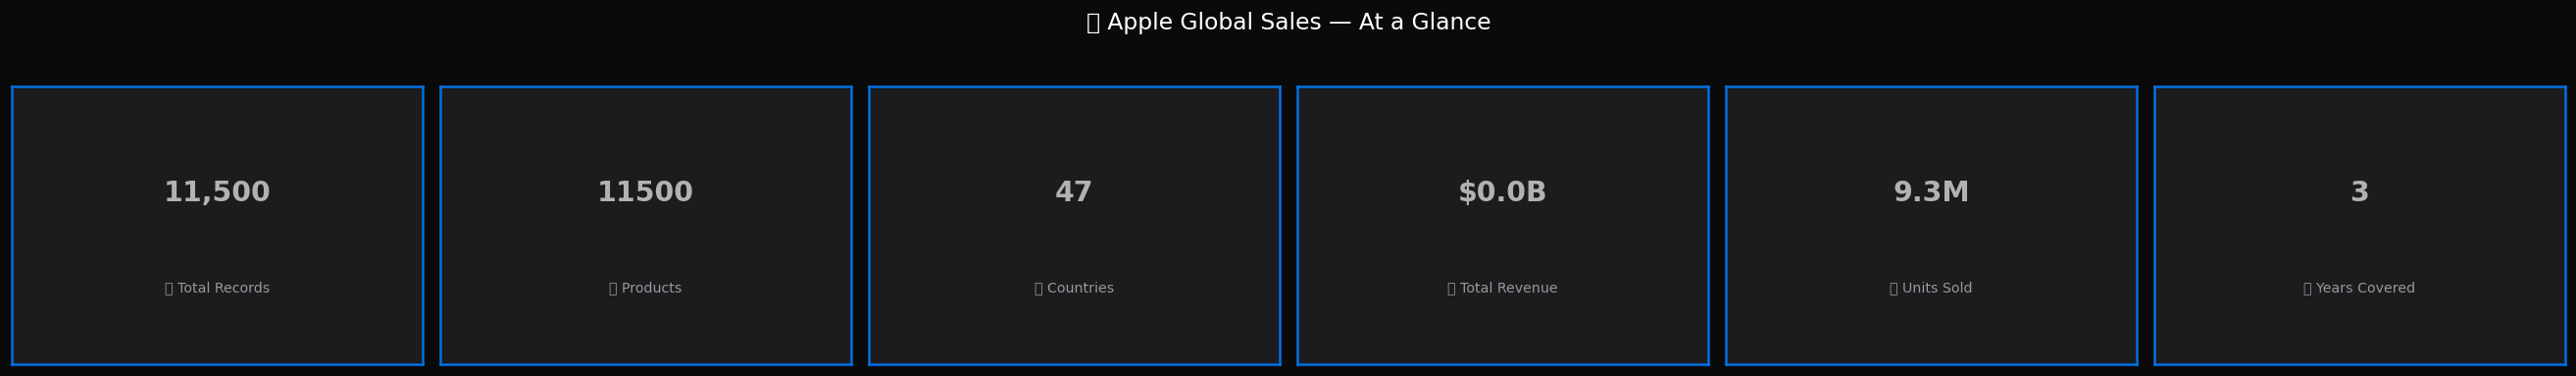

In [15]:
# ── Sales by Product Category ─────────────────────────────────────────────────
cat_col = next((c for c in df.columns if 'category' in c or 'product_type' in c
                or 'product_name' in c), cat_cols[0] if cat_cols else None)

if cat_col and rev_col:
    cat_rev = df.groupby(cat_col)[rev_col].sum().sort_values(ascending=False).reset_index()
    cat_rev.columns = ['category','total_revenue']

    fig = make_subplots(rows=1, cols=2,
                        specs=[[{'type':'bar'},{'type':'pie'}]],
                        subplot_titles=['Revenue by Category','Revenue Share %'])

    fig.add_trace(
        go.Bar(x=cat_rev['category'], y=cat_rev['total_revenue'],
               marker_color=APPLE_PALETTE[:len(cat_rev)],
               text=cat_rev['total_revenue'].apply(lambda x: f'${x/1e9:.1f}B' if x>=1e9 else f'${x/1e6:.0f}M'),
               textposition='outside', name='Revenue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Pie(labels=cat_rev['category'], values=cat_rev['total_revenue'],
               hole=0.45, marker_colors=APPLE_PALETTE[:len(cat_rev)]),
        row=1, col=2
    )
    fig.update_layout(title='📱 Revenue Breakdown by Product Category',
                      template='plotly_dark', height=450, showlegend=False)
    fig.update_xaxes(tickangle=-30, row=1, col=1)
    fig.show()

In [19]:
# ── Units Sold by Category ────────────────────────────────────────────────────
if cat_col and units_col:
    cat_units = df.groupby(cat_col)[units_col].sum().sort_values(ascending=False).reset_index()
    cat_units.columns = ['category','units_sold']

    fig = px.histogram(
        cat_units, x='units_sold', y='category',
        color='category',
        title='🔽 Units Sold Funnel by Product Category',
        color_discrete_sequence=APPLE_PALETTE
    )
    fig.update_layout(template='plotly_dark', showlegend=False)
    fig.show()

#  create the cleaned data CSV file

In [13]:
os.makedirs( '../data/cleaned data', exist_ok = True )

In [14]:
df.to_csv( '../data/cleaned data/cleaned_data.csv', index = False )